# Neural Networks for Biochemistry
In this example we will predict melting temperature from the one hot encoding of protein sequences. We will use the promelt dataset (https://zenodo.org/records/20067528 and is associated with the following paper: Pailozian, et al. Investigation of Protein Melting Temperature Prediction with Cross-Method Validation on Biophysical Data. bioRxiv, 2026. https://doi.org/10.64898/2026.05.07.723192)

# Install packages
only run if you do not have these packages installed

In [ ]:
%pip install rdkit
%pip install pandas
%pip install scikit-learn
%pip install matplotlib
%pip install torch torchvision torchaudio #note this will install pytorch for CPU

# Loading data

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Standard 20 amino acids
AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"

aa_to_idx = {aa: i for i, aa in enumerate(AMINO_ACIDS)}

def one_hot_encode_proteins(
    df,
    sequence_col="sequence",
    max_length=None,
    encoding_col="one_hot",
    mask_col="mask"
):
    """
    One-hot encode protein sequences in a pandas DataFrame.

    The one-hot encoding and mask are added as new columns to the dataframe.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing protein sequences.

    sequence_col : str, default="sequence"
        Column containing protein sequences.

    max_length : int or None, default=None
        Maximum sequence length to encode.
        If None, uses the longest sequence in the dataframe.

    encoding_col : str, default="one_hot"
        Name of the column containing the one-hot encoded arrays.

    mask_col : str, default="mask"
        Name of the column containing the masks.

    Returns
    -------
    pandas.DataFrame
        DataFrame with one-hot encoding and mask columns added.
    """

    sequences = df[sequence_col].astype(str).str.upper().tolist()

    # Determine maximum length
    if max_length is None:
        max_length = max(len(seq) for seq in sequences)
    elif not isinstance(max_length, int) or max_length <= 0:
        raise ValueError("max_length must be a positive integer or None.")

    encoded = np.zeros(
        (len(sequences), max_length, len(AMINO_ACIDS)),
        dtype=np.float32
    )

    mask = np.zeros(
        (len(sequences), max_length),
        dtype=bool
    )

    for i, seq in enumerate(sequences):

        # Truncate sequence if necessary
        seq = seq[:max_length]

        for j, aa in enumerate(seq):

            if aa not in aa_to_idx:
                raise ValueError(
                    f"Unknown amino acid '{aa}' in sequence {i} "
                    f"at position {j}"
                )

            encoded[i, j, aa_to_idx[aa]] = 1.0

        # Mark actual sequence positions
        mask[i, :len(seq)] = True
    
    #reshape ohe so that it is flat for input to the neural network
    encoded = encoded.reshape(len(sequences), -1)
    # Add each sequence's array to the corresponding dataframe row
    df[encoding_col] = list(encoded)
    df[mask_col] = list(mask)

    return df

df = pd.read_csv("full_promelt_seq.csv")
#remove rows with invalid amino acids
df = df[df["sequence"].str.count("X")==0]
df = df[df["sequence"].str.count("U")==0]
df = df[df["sequence"].str.count("Z")==0]
df = df[df["sequence"].str.count("B")==0]

#remove rows with very long sequences
df = df[df["Length"]<1000]

df = one_hot_encode_proteins(df)
df['stable'] = df["Tm"] > 55
df


,ProteinID,Organism,Tm,Method,cluster#,cluster_count,Length,sequence,one_hot,mask,stable
0,I1W5V5,Oleispira antarctica,38.47000,Meltome/TPP,2524,10,279,MSIENLSSNKSFGGWHKQYSHVSNTLNCAMRFAIYLPPQASTGAKV...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[True, True, True, True, True, True, True, Tru...",False
1,R4YJ85,Oleispira antarctica,37.96000,Meltome/TPP,6917,1,545,MINLEKALAGRRILIVDDLVEARSSLKKMATILGGDNIDVATDGIE...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[True, True, True, True, True, True, True, Tru...",False
2,R4YJ88,Oleispira antarctica,51.24000,Meltome/TPP,15606,1,215,MIRRIVASAAILFASFNSFAADNHDHQEAPIADMSKAYTLLDQPQA...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[True, True, True, True, True, True, True, Tru...",False
3,R4YJ93,Oleispira antarctica,41.36000,Meltome/TPP,15607,1,330,MKLRFSRSSLNLIIFTCIILIGWASIDANINKQHTEDSRKTEIIVL...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[True, True, True, True, True, True, True, Tru...",False
4,R4YJ97,Oleispira antarctica,41.99000,Meltome/TPP,0,1,397,MPEHIPADSVGIISPKVQRFDEPLTLRSGRILESYELIYETYGELN...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[True, True, True, True, True, True, True, Tru...",False
...,...,...,...,...,...,...,...,...,...,...,...
41540,A0A125YRY2,Toxoplasma gondii,57.54923,TPP/ProTherm,15604,1,389,MYSLGVEGDETLLAQNQLSMSSRQGTGYMVGHHTMSSTMGGAAPAV...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[True, True, True, True, True, True, True, Tru...",True
41541,S7URD1,Toxoplasma gondii,51.87692,TPP/ProTherm,13796,1,929,MRGPLGRGAGGGVASDDRTRGMSDLGKSFQPDGPPTPPDTPHRNFI...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[True, True, True, True, True, True, True, Tru...",False
41543,S7UYZ6,Toxoplasma gondii,43.12291,TPP/ProTherm,6915,1,355,MVDYSKWERLQVSSSDEEEAGGKPRVRRFEEKQRVTVGPEGVFIEG...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[True, True, True, True, True, True, True, Tru...",False
41544,S7UHE6,Toxoplasma gondii,58.30436,TPP/ProTherm,13798,1,584,MDAEETNLGFLVAAHPQRLRRWHFPSKVGGKPEWMETRRLPKTEDL...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[True, True, True, True, True, True, True, Tru...",True


# Classification Neural Network
We will set up a fully-connected neural network to classify stability from one hot encoding

Epoch  1 | Train Loss: 0.5036 | Train Acc: 0.7679 | Validation Acc: 0.7805
Epoch  2 | Train Loss: 0.2200 | Train Acc: 0.9094 | Validation Acc: 0.7765
Epoch  3 | Train Loss: 0.0805 | Train Acc: 0.9732 | Validation Acc: 0.7785
Epoch  4 | Train Loss: 0.0381 | Train Acc: 0.9881 | Validation Acc: 0.7710
Epoch  5 | Train Loss: 0.0175 | Train Acc: 0.9944 | Validation Acc: 0.7745
Epoch  6 | Train Loss: 0.0129 | Train Acc: 0.9968 | Validation Acc: 0.7755
Epoch  7 | Train Loss: 0.0072 | Train Acc: 0.9978 | Validation Acc: 0.7745
Epoch  8 | Train Loss: 0.0038 | Train Acc: 0.9984 | Validation Acc: 0.7745
Epoch  9 | Train Loss: 0.0054 | Train Acc: 0.9986 | Validation Acc: 0.7780
Epoch 10 | Train Loss: 0.0024 | Train Acc: 0.9991 | Validation Acc: 0.7775
Epoch 11 | Train Loss: 0.0011 | Train Acc: 0.9995 | Validation Acc: 0.7745
Epoch 12 | Train Loss: 0.0010 | Train Acc: 0.9996 | Validation Acc: 0.7745
Epoch 13 | Train Loss: 0.0009 | Train Acc: 0.9995 | Validation Acc: 0.7740
Epoch 14 | Train Loss: 0.

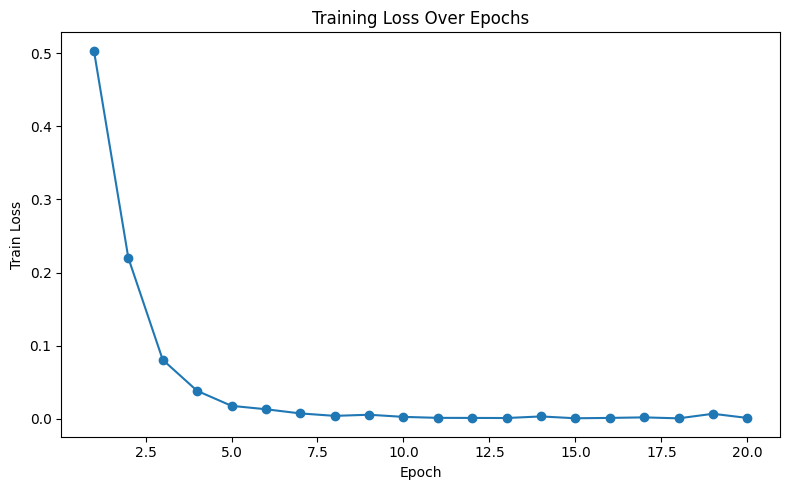

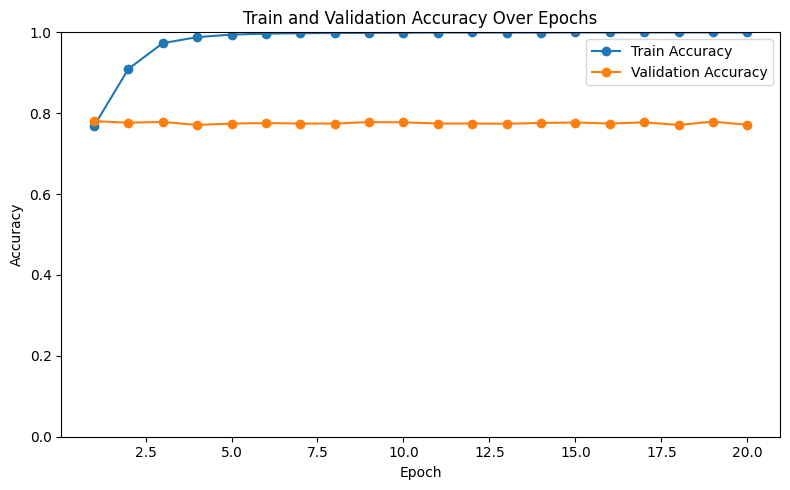

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

#use only part of data to make training faster
df = df[0:10000]

#prepare data for pytorch
X = np.stack(df["one_hot"].values)   # shape: (n_samples, n_features)
y = df["stable"].values.astype(np.float32)

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

#split data
#note we will call the split the train/validation split because we will be using the validation data to monitor
#the progress of the neural network's training
#if you want a true test set that could also be split off at this time
X_train, X_val, y_train, y_val = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42, stratify=y_tensor
)

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

#this class defines the neural network architecture
class BinaryFCNN(nn.Module):
    def __init__(self, input_dim, hidden_dim1, hidden_dim2):
        super().__init__() # this initializes the superclass (nn.Module) which lets this class use pytorch module methods
        #nn.Sequential sets up each layer
        #Linear is a fully connected layer, arguments are input and output dimension
        #ReLU activation layers alternate until final output layer
        #to add more layers, just add more to the nn.Sequenquential list
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Linear(hidden_dim2, 1)
        )
    
    #this will  run the model in the forward direction (make predictions)
    def forward(self, x):
        return self.model(x).squeeze(1)
    
input_dim = X.shape[1]
model = BinaryFCNN(input_dim=input_dim, hidden_dim1=256, hidden_dim2=128)

#set the loss (criterion), optimizer, and number of epochs
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 20

train_losses = []
train_accuracies = []
val_accuracies = []

#train the model
for epoch in range(num_epochs):
    #set model in train mode so weights can change
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()

        logits = model(batch_X)
        loss = criterion(logits, batch_y)

        loss.backward() #back propagation
        optimizer.step()

        running_loss += loss.item() * batch_X.size(0)

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()

        correct += (preds == batch_y).sum().item()
        total += batch_y.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    
    #set model into eval mode, doesn't use dropout and use running statistics
    model.eval()
    val_correct = 0
    val_total = 0

    #turn off gradient, this will keep any weights from being accidently changed
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            logits = model(batch_X)
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()
            val_correct += (preds == batch_y).sum().item()
            val_total += batch_y.size(0)

    val_acc = val_correct / val_total
    
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(
        f"Epoch {epoch+1:2d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Validation Acc: {val_acc:.4f}"
    )

# Plot train loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Training Loss Over Epochs")
plt.tight_layout()
plt.show()

# Plot train and test accuracy
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_accuracies, marker='o', label="Train Accuracy")
plt.plot(range(1, num_epochs + 1), val_accuracies, marker='o', label="Validation Accuracy")
plt.ylim(0,1)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train and Validation Accuracy Over Epochs")
plt.legend()
plt.tight_layout()
plt.show()

# Dropout
How overfit is our model? Dropout can help with overfitting by preventing the model from relying too much on individual neurons or specific combinations of neurons. Try changing the dropout rate hyperparameter and see how it affects the results.

Epoch  1 | Train Loss: 0.5178 | Train Acc: 0.7562 | Validation Acc: 0.7700
Epoch  2 | Train Loss: 0.2687 | Train Acc: 0.8860 | Validation Acc: 0.7745
Epoch  3 | Train Loss: 0.1122 | Train Acc: 0.9639 | Validation Acc: 0.7535
Epoch  4 | Train Loss: 0.0575 | Train Acc: 0.9859 | Validation Acc: 0.7720
Epoch  5 | Train Loss: 0.0354 | Train Acc: 0.9904 | Validation Acc: 0.7735
Epoch  6 | Train Loss: 0.0245 | Train Acc: 0.9926 | Validation Acc: 0.7750
Epoch  7 | Train Loss: 0.0168 | Train Acc: 0.9949 | Validation Acc: 0.7715
Epoch  8 | Train Loss: 0.0137 | Train Acc: 0.9961 | Validation Acc: 0.7740
Epoch  9 | Train Loss: 0.0161 | Train Acc: 0.9968 | Validation Acc: 0.7625
Epoch 10 | Train Loss: 0.0085 | Train Acc: 0.9971 | Validation Acc: 0.7605
Epoch 11 | Train Loss: 0.0085 | Train Acc: 0.9988 | Validation Acc: 0.7690
Epoch 12 | Train Loss: 0.0134 | Train Acc: 0.9970 | Validation Acc: 0.7665
Epoch 13 | Train Loss: 0.0165 | Train Acc: 0.9970 | Validation Acc: 0.7685
Epoch 14 | Train Loss: 0.

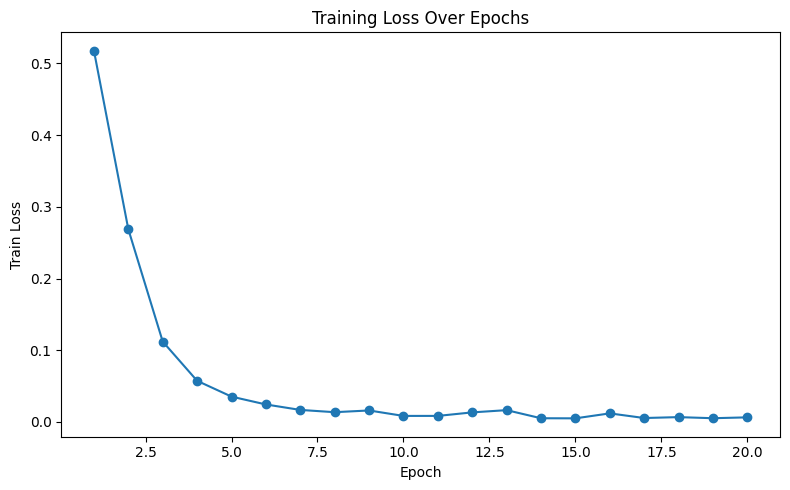

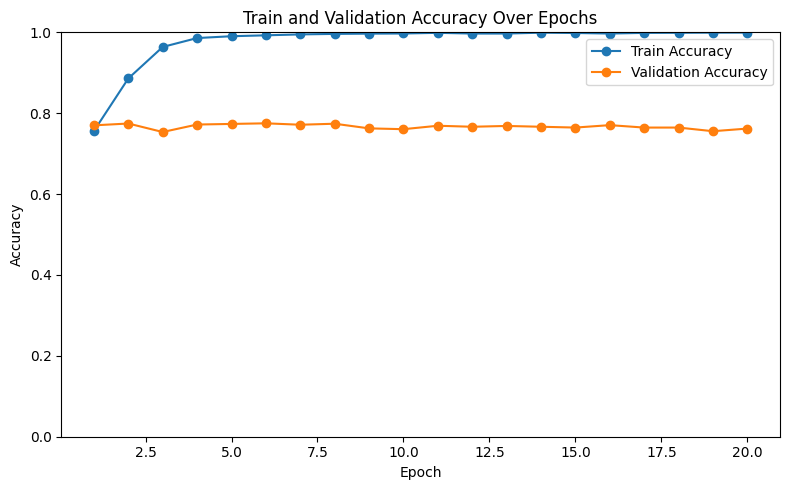

In [3]:
#this class defines the neural network architecture
class BinaryFCNN(nn.Module):
    def __init__(self, input_dim, hidden_dim1, hidden_dim2, dropout_rate=0.3):
        super().__init__()
        #nn.Sequential sets up each layer
        #Linear is a fully connected layer, arguments are input and output dimension
        #ReLU activation layers alternate until final output layer
        #to add more layers, just add more to the nn.Sequenquential list
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim2, 1)
        )
    
    #this will  run the model in the forward direction (make predictions)
    def forward(self, x):
        return self.model(x).squeeze(1)

input_dim = X.shape[1]
model = BinaryFCNN(input_dim=input_dim, hidden_dim1=256, hidden_dim2=128)

#set the loss (criterion), optimizer, and number of epochs
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 20

train_losses = []
train_accuracies = []
val_accuracies = []

#train the model
for epoch in range(num_epochs):
    #set model in train mode so weights can change
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()

        logits = model(batch_X)
        loss = criterion(logits, batch_y)

        loss.backward() #back propagation
        optimizer.step()

        running_loss += loss.item() * batch_X.size(0)

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()

        correct += (preds == batch_y).sum().item()
        total += batch_y.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    
    #set model into eval mode, doesn't use dropout and use running statistics
    model.eval()
    val_correct = 0
    val_total = 0

    #turn off gradient, this will keep any weights from being accidently changed
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            logits = model(batch_X)
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()
            val_correct += (preds == batch_y).sum().item()
            val_total += batch_y.size(0)

    val_acc = val_correct / val_total
    
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(
        f"Epoch {epoch+1:2d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Validation Acc: {val_acc:.4f}"
    )

# Plot train loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Training Loss Over Epochs")
plt.tight_layout()
plt.show()

# Plot train and test accuracy
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_accuracies, marker='o', label="Train Accuracy")
plt.plot(range(1, num_epochs + 1), val_accuracies, marker='o', label="Validation Accuracy")
plt.ylim(0,1)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train and Validation Accuracy Over Epochs")
plt.legend()
plt.tight_layout()
plt.show()

# Further analyze performance on validation data
Plot ROC and PRC curves

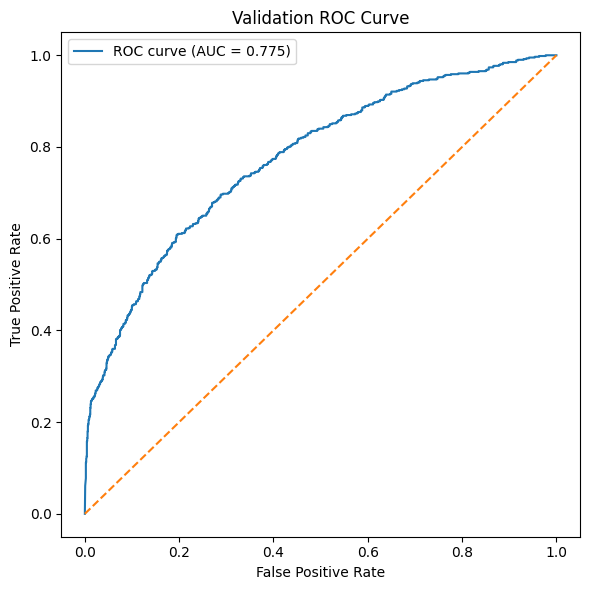

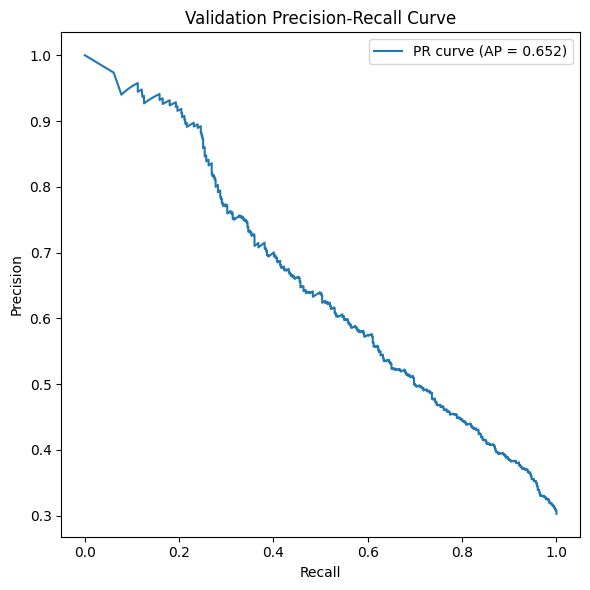

In [4]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

#remember to turn model into eval mode and use no_grad when applying model
model.eval()

all_probs = []
all_true = []

with torch.no_grad():
    for batch_X, batch_y in val_loader:
        logits = model(batch_X)                  # shape: (batch_size,)
        probs = torch.sigmoid(logits)            # convert logits to probabilities
        all_probs.extend(probs.cpu().numpy())
        all_true.extend(batch_y.cpu().numpy())

all_probs = np.array(all_probs)
all_true = np.array(all_true)

# ROC curve
fpr, tpr, _ = roc_curve(all_true, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Validation ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

# Precision-recall curve
precision, recall, _ = precision_recall_curve(all_true, all_probs)
ap = average_precision_score(all_true, all_probs)

plt.figure(figsize=(6, 6))
plt.plot(recall, precision, label=f"PR curve (AP = {ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Validation Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.show()

# Regression
Now let's rewrite the network so that it performs regression on the Tm rather than a classification

Epoch  1 | Train Loss: 424.1799 | Validation Loss: 148.6735 | Train RMSE: 20.5956 | Validation RMSE: 12.1932 | Train R2: -0.9855 | Validation R2: 0.2951
Epoch  2 | Train Loss: 132.4058 | Validation Loss: 145.8922 | Train RMSE: 11.5068 | Validation RMSE: 12.0786 | Train R2: 0.3802 | Validation R2: 0.3083
Epoch  3 | Train Loss: 97.9978 | Validation Loss: 146.3676 | Train RMSE: 9.8994 | Validation RMSE: 12.0982 | Train R2: 0.5413 | Validation R2: 0.3060
Epoch  4 | Train Loss: 85.1262 | Validation Loss: 154.7443 | Train RMSE: 9.2264 | Validation RMSE: 12.4396 | Train R2: 0.6016 | Validation R2: 0.2663
Epoch  5 | Train Loss: 75.0923 | Validation Loss: 154.5883 | Train RMSE: 8.6656 | Validation RMSE: 12.4334 | Train R2: 0.6485 | Validation R2: 0.2671
Epoch  6 | Train Loss: 72.7189 | Validation Loss: 161.0592 | Train RMSE: 8.5275 | Validation RMSE: 12.6909 | Train R2: 0.6596 | Validation R2: 0.2364
Epoch  7 | Train Loss: 66.1597 | Validation Loss: 157.8532 | Train RMSE: 8.1339 | Validation RM

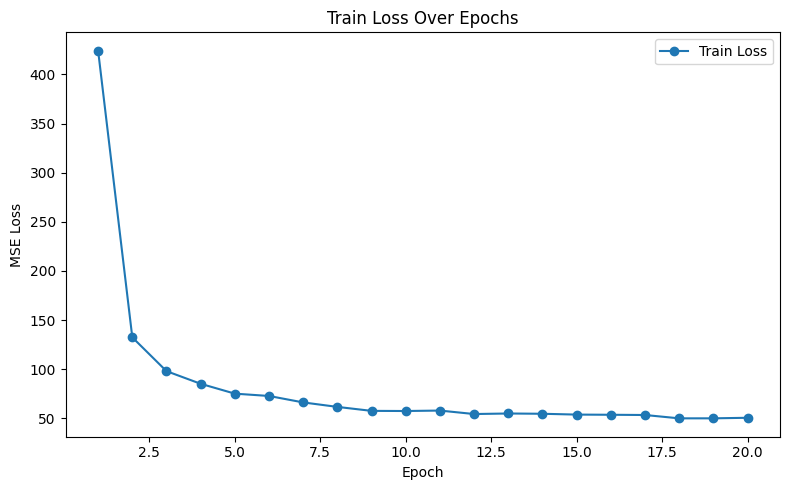

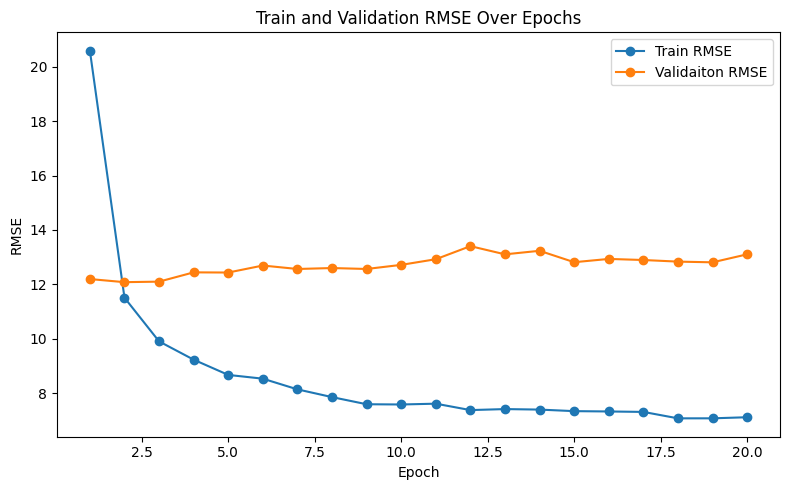

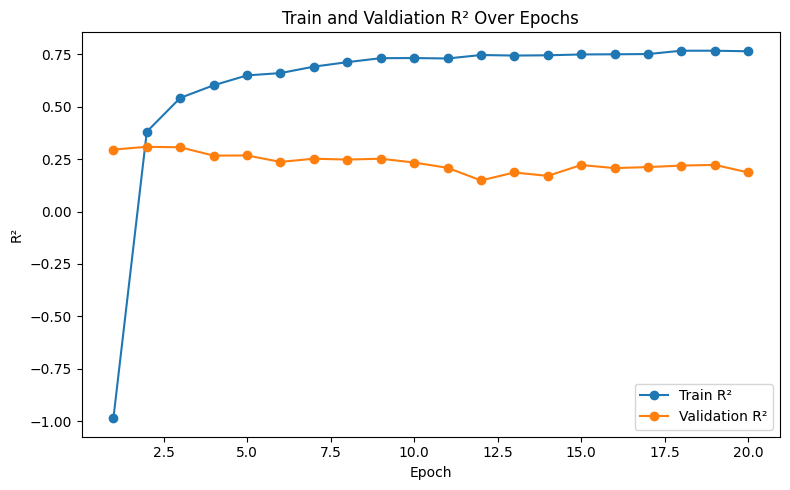

In [5]:
from sklearn.metrics import mean_squared_error, r2_score

#prepare data for pytorch
X = np.stack(df["one_hot"].values)   # shape: (n_samples, n_features)
y = df["Tm"].values.astype(np.float32)

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

#split data
X_train, X_val, y_train, y_val = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42
)

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

class RegressionFCNN(nn.Module):
    def __init__(self, input_dim, hidden_dim1, hidden_dim2, dropout_rate=0.3):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(hidden_dim2, 1)
        )

    def forward(self, x):
        return self.model(x).squeeze(1)


input_dim = X.shape[1]

model = RegressionFCNN(
    input_dim=input_dim,
    hidden_dim1=256,
    hidden_dim2=128,
    dropout_rate=0.3
)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 20

train_losses = []
val_losses = []

train_rmses = []
val_rmses = []

train_r2s = []
val_r2s = []

    
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    total = 0
    
    train_preds = []
    train_true = []

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()

        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_X.size(0)
        total += batch_X.size(0)
        
        #use .detach() for tensors associated with gradients
        train_preds.extend(predictions.cpu().detach().numpy())
        train_true.extend(batch_y.cpu().numpy())

    train_loss = running_loss / total
    train_losses.append(train_loss)
    train_rmse = np.sqrt(mean_squared_error(train_true, train_preds))
    train_r2 = r2_score(train_true, train_preds)
    train_rmses.append(train_rmse)
    train_r2s.append(train_r2)

    # Evaluate on validation set
    model.eval()
    val_running_loss = 0.0
    val_total = 0
    val_preds = []
    val_true = []

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)

            val_running_loss += loss.item() * batch_X.size(0)
            val_total += batch_X.size(0)

            val_preds.extend(predictions.cpu().numpy())
            val_true.extend(batch_y.cpu().numpy())

    val_loss = val_running_loss / val_total
    val_rmse = np.sqrt(mean_squared_error(val_true, val_preds))
    val_r2 = r2_score(val_true, val_preds)

    
    val_losses.append(val_loss)
    val_rmses.append(val_rmse)
    val_r2s.append(val_r2)

    print(
        f"Epoch {epoch+1:2d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Validation Loss: {val_loss:.4f} | "
        f"Train RMSE: {train_rmse:.4f} | "
        f"Validation RMSE: {val_rmse:.4f} | "
        f"Train R2: {train_r2:.4f} | "
        f"Validation R2: {val_r2:.4f}"
    )

# Plot train and test loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o', label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Train Loss Over Epochs")
plt.legend()
plt.tight_layout()
plt.show()

# Plot train and test RMSE
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_rmses, marker='o', label="Train RMSE")
plt.plot(range(1, num_epochs + 1), val_rmses, marker='o', label="Validaiton RMSE")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Train and Validation RMSE Over Epochs")
plt.legend()
plt.tight_layout()
plt.show()

# Plot train and test R2
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_r2s, marker='o', label="Train R²")
plt.plot(range(1, num_epochs + 1), val_r2s, marker='o', label="Validation R²")
plt.xlabel("Epoch")
plt.ylabel("R²")
plt.title("Train and Valdiation R² Over Epochs")
plt.legend()
plt.tight_layout()
plt.show()


# More Performance Analysis
plot actual vs predicted for regression task

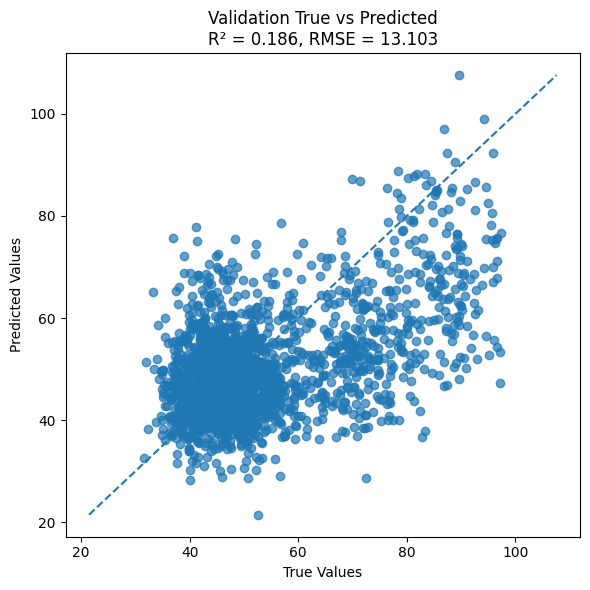

In [6]:
model.eval()

all_preds = []
all_true = []

with torch.no_grad():
    for batch_X, batch_y in val_loader:
        preds = model(batch_X)

        all_preds.extend(preds.cpu().numpy())
        all_true.extend(batch_y.cpu().numpy())

all_preds = np.array(all_preds)
all_true = np.array(all_true)

r2 = r2_score(all_true, all_preds)
rmse = np.sqrt(mean_squared_error(all_true, all_preds))

plt.figure(figsize=(6, 6))
plt.scatter(all_true, all_preds, alpha=0.7)

min_val = min(all_true.min(), all_preds.min())
max_val = max(all_true.max(), all_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title(f"Validation True vs Predicted\nR² = {r2:.3f}, RMSE = {rmse:.3f}")
plt.tight_layout()
plt.show()

# Getting information about the model
Sometimes we want to check the architecture of our model or calculate the number of parameters (weights). Knowing the number of parameters relative to the number of training data points can help assess our risk of overfitting.

In [9]:
#to get the model architecture you can print it
print(model)

#we can sum the parameters over all layers
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

#parameters by layer
for name, param in model.named_parameters():
    print(
        name,
        param.shape,
        param.numel(),
        param.requires_grad
    )

#because the one hot encoding input is very large, we will have many parameters from the first layer
#this may be contributing to our overfitting problem

RegressionFCNN(
  (model): Sequential(
    (0): Linear(in_features=19980, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=1, bias=True)
  )
)
Total parameters: 5,148,161
model.0.weight torch.Size([256, 19980]) 5114880 True
model.0.bias torch.Size([256]) 256 True
model.3.weight torch.Size([128, 256]) 32768 True
model.3.bias torch.Size([128]) 128 True
model.6.weight torch.Size([1, 128]) 128 True
model.6.bias torch.Size([1]) 1 True
